In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

  Using cached qiskit-1.2.4-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (12 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached symengine-0.13.0.tar.gz (114 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
Using cached qiskit-1.2.4-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (4.8 MB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
  error: subprocess-exited-with-error
  
  × Building wheel for symengine (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [30 lines of output]
      /tmp/pip-build-env-pcph4e9i/overlay/lib/python3.14/site-packages/setuptools/_vendor/wheel/bdist_wheel.py:4: FutureWarning: The 'wheel' package is no longer the canonical location of th

In [2]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# This notebook is for a simulation of the protocol without an attacker.

In [ ]:
backend = BasicSimulator()

def measure_bit(circuit):
    compiled = transpile(circuit, backend)
    job = backend.run(compiled, shots=1)
    result = job.result()
    counts = result.get_counts(compiled)
    return int(list(counts.keys())[0])

def random_bits(n):
    bits = []
    for i in range(n):
        qc = QuantumCircuit(1, 1)
        qc.h(0)
        qc.measure(0, 0)
        bits = bits + [measure_bit(qc)]
    return bits

def prepare_bb84_qubit(bit, basis):
    qc = QuantumCircuit(1, 1)
    if bit == 1:
        qc.x(0)
    if basis == 1:
        qc.h(0)
    return qc

def measure_bb84_qubit(bit, alice_basis, bob_basis):
    qc = prepare_bb84_qubit(bit, alice_basis)
    if bob_basis == 1:
        qc.h(0)
    qc.measure(0, 0)
    return measure_bit(qc)

def basis_name(basis):
    if basis == 0:
        return "Z"
    else:
        return "X"

def bits_to_string(bits):
    return "".join([str(bit) for bit in bits])

def print_plain_report(n, alice_bits, alice_bases, bob_bases, bob_results, matching_positions, alice_key, bob_key):
    print("BB84 without attacker")
    print("---------------------")
    print("Basis names: Z = computational, X = diagonal")
    print("Number of qubits sent:", n)
    print("Matching bases:", len(matching_positions))
    print("Sifted key length:", len(alice_key))
    print("Alice sifted key:", bits_to_string(alice_key))
    print("Bob sifted key:  ", bits_to_string(bob_key))
    print("Keys match:", alice_key == bob_key)
    print()
    print("Position | Alice bit | Alice basis | Bob basis | Bob result | Keep")
    print("-------------------------------------------------------------------")
    for i in range(n):
        keep = "Yes" if i in matching_positions else "No"
        print(f"{i:>8} | {alice_bits[i]:>9} | {basis_name(alice_bases[i]):>11} | {basis_name(bob_bases[i]):>9} | {bob_results[i]:>10} | {keep}")

BB84 without attacker
---------------------
Basis names: Z = computational, X = diagonal
Number of qubits sent: 20
Matching bases: 8
Sifted key length: 8
Alice sifted key: 01001101
Bob sifted key:   01001101
Keys match: True

Position | Alice bit | Alice basis | Bob basis | Bob result | Keep
-------------------------------------------------------------------
       0 |         1 |           X |         Z |          1 | No
       1 |         0 |           X |         X |          0 | Yes
       2 |         1 |           Z |         X |          1 | No
       3 |         1 |           X |         X |          1 | Yes
       4 |         0 |           Z |         X |          1 | No
       5 |         0 |           Z |         Z |          0 | Yes
       6 |         1 |           X |         Z |          0 | No
       7 |         0 |           X |         Z |          1 | No
       8 |         0 |           X |         Z |          1 | No
       9 |         0 |           Z |         Z |   

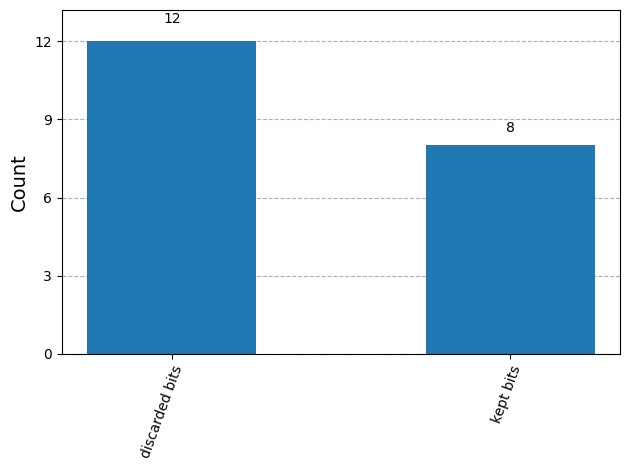

In [4]:
# BB84 without an attacker

n = 20

# Alice chooses random bits and random bases.
alice_bits = random_bits(n)
alice_bases = random_bits(n)

# Bob chooses random bases.
bob_bases = random_bits(n)

# Bob measures each qubit that Alice sends.
bob_results = []
for i in range(n):
    bob_results = bob_results + [measure_bb84_qubit(alice_bits[i], alice_bases[i], bob_bases[i])]

# Alice and Bob compare bases publicly and keep only matching positions.
matching_positions = []
for i in range(n):
    if alice_bases[i] == bob_bases[i]:
        matching_positions = matching_positions + [i]

alice_key = [alice_bits[i] for i in matching_positions]
bob_key = [bob_results[i] for i in matching_positions]

print_plain_report(n, alice_bits, alice_bases, bob_bases, bob_results, matching_positions, alice_key, bob_key)

plot_histogram({"kept bits": len(matching_positions), "discarded bits": n - len(matching_positions)})